
--- Instance Plot Debug ---
theta2_instance = 0.7853981633974483
Calculated Ax_inst = 1.4142, Ay_inst = 1.4142
Returned Px_inst = 0.1269, Py_inst = 3.5573
Difference Px-Ax = -1.2873
Difference Py-Ay = 2.1431
Is P visually == A? False
--- End Instance Plot Debug ---


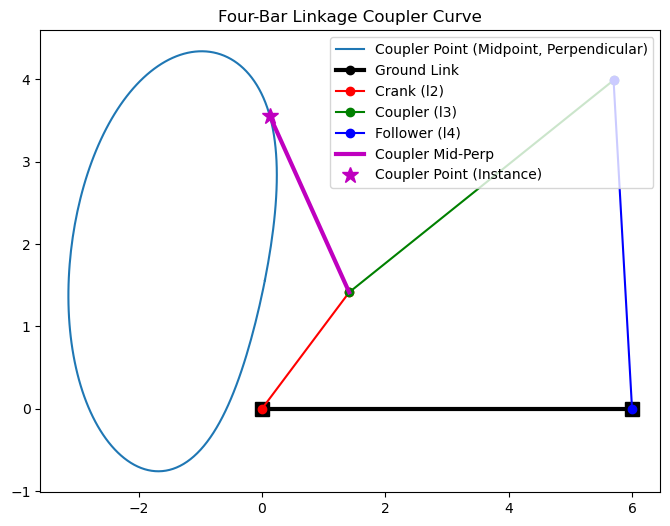


Testing Edge Cases:
Non-assemblable linkage (l3=1.0): Px=1.2757339458737802, Py=1.8946543972468626 (Expect NaN)
Near singularity (l1=l2, theta2=0): Px=nan, Py=nan


In [11]:
import numpy as np

def simulate_four_bar_coupler_point(l1, l2, l3, l4, theta2_rad, P_dist_ratio=0.5, P_angle_offset_rad=np.pi/2):
    
    # Store original shape and convert to at least 1D numpy array
    input_val = theta2_rad
    theta2_rad = np.atleast_1d(np.asarray(input_val)) # Ensure it's at least 1D
    is_scalar_input = (theta2_rad.ndim == 1 and theta2_rad.size == 1) # Check if original input was scalar-like

    # Initialize output arrays with NaN (matching input shape)
    Px = np.full(theta2_rad.shape, np.nan)
    Py = np.full(theta2_rad.shape, np.nan)

    # Position of pivot A (crank-coupler joint)
    Ax = l2 * np.cos(theta2_rad)
    Ay = l2 * np.sin(theta2_rad)

    # Calculate distance squared and distance from O4 to A (diagonal d)
    d_sq = (Ax - l1)**2 + Ay**2
    
    epsilon = 1e-12 
    valid_d_sq = d_sq > epsilon 
    d = np.full(theta2_rad.shape, np.nan)
    # Use np.where for conditional assignment based on valid_d_sq mask
    d = np.where(valid_d_sq, np.sqrt(d_sq), np.nan) 

    # Calculate arccos arguments, handle potential division by zero using np.where
    cos_phi_arg = np.full(theta2_rad.shape, np.nan)
    cos_psi_arg = np.full(theta2_rad.shape, np.nan)
    
    # Calculate only where d is valid
    valid_d = ~np.isnan(d) & (d > epsilon) & (l3 > epsilon) & (l4 > epsilon)
    if np.any(valid_d):
        # Use np.divide for safe division, outputting NaN where denominator is zero (or d is NaN)
        safe_denom_phi = 2 * d[valid_d] * l4
        safe_denom_psi = 2 * d[valid_d] * l3
        
        cos_phi_arg[valid_d] = (d_sq[valid_d] + l4**2 - l3**2) / safe_denom_phi
        cos_psi_arg[valid_d] = (d_sq[valid_d] + l3**2 - l4**2) / safe_denom_psi

    # Check if arguments are within valid range [-1, 1]
    valid_assembly = valid_d & \
                     (np.abs(cos_phi_arg) <= 1.0 + epsilon) & \
                     (np.abs(cos_psi_arg) <= 1.0 + epsilon) # Add tolerance for float errors

    # Process only the angles where assembly is possible
    if np.any(valid_assembly):
        # Clip args strictly within bounds for arccos
        safe_cos_phi_arg = np.clip(cos_phi_arg[valid_assembly], -1.0, 1.0)
        phi = np.arccos(safe_cos_phi_arg)

        # Angle alpha of the diagonal O4A relative to the positive X-axis
        alpha = np.arctan2(Ay[valid_assembly] - 0, Ax[valid_assembly] - l1)

        # Calculate follower angle theta4 
        theta4 = alpha - phi

        # Calculate position of pivot B 
        Bx = l1 + l4 * np.cos(theta4)
        By = l4 * np.sin(theta4)

        # Calculate coupler angle theta3
        theta3 = np.arctan2(By - Ay[valid_assembly], Bx - Ax[valid_assembly])

        # Calculate the coupler point P position
        P_dist = l3 * P_dist_ratio
        
        # Apply results using the valid_assembly mask
        Px[valid_assembly] = Ax[valid_assembly] + P_dist * np.cos(theta3 + P_angle_offset_rad)
        Py[valid_assembly] = Ay[valid_assembly] + P_dist * np.sin(theta3 + P_angle_offset_rad)

    # If the original input was scalar, return scalar outputs
    if is_scalar_input:
        return Px.item(), Py.item() # .item() extracts the scalar value
    else:
        return Px, Py

# --- Example Usage ---
if __name__ == '__main__':
    # Example: A crank-rocker mechanism (satisfies Grashof)
    l_ground = 6.0
    l_crank = 2.0  # Shortest, adjacent to ground
    l_coupler = 5.0
    l_follower = 4.0
    
    # Check Grashof: S+L <= P+Q => 2+6 <= 5+4 => 8 <= 9 (True)
    # Crank-rocker because shortest (crank) is adjacent to ground.

    # Generate a full rotation of the crank
    num_points = 180
    theta2_sweep = np.linspace(0, 2 * np.pi, num_points)

    # Calculate coupler path (midpoint, perpendicular)
    Px_mid, Py_mid = simulate_four_bar_coupler_point(l_ground, l_crank, l_coupler, l_follower, theta2_sweep, 0.5)

    # Calculate coupler path (endpoint, inline -> P_dist_ratio=1, P_angle_offset=0)
    # Px_end, Py_end = simulate_four_bar_coupler_point(l_ground, l_crank, l_coupler, l_follower, theta2_sweep, P_dist_ratio=1.0, P_angle_offset_rad=0.0)


    # --- Plotting (Optional, requires matplotlib) ---
    try:
        import matplotlib.pyplot as plt
        
        plt.figure(figsize=(8, 6))
        # Plot the main curve (Px_mid, Py_mid)
        plt.plot(Px_mid, Py_mid, label=f'Coupler Point (Midpoint, Perpendicular)') 

        # Plot mechanism base
        plt.plot([0, l_ground], [0, 0], 'ko-', label='Ground Link', linewidth=3)
        plt.plot(0, 0, 'ks', markersize=10) # Pivot O2
        plt.plot(l_ground, 0, 'ks', markersize=10) # Pivot O4

        # Plot one instance of the mechanism (e.g., at theta2=pi/4)
        theta2_instance = np.pi / 4
        Px_inst, Py_inst = simulate_four_bar_coupler_point(l_ground, l_crank, l_coupler, l_follower, theta2_instance, 0.5)
        
        Ax_inst = l_crank * np.cos(theta2_instance)
        Ay_inst = l_crank * np.sin(theta2_instance)
        
        # --- START INSTANCE DEBUG ---
        print(f"\n--- Instance Plot Debug ---")
        print(f"theta2_instance = {theta2_instance}")
        print(f"Calculated Ax_inst = {Ax_inst:.4f}, Ay_inst = {Ay_inst:.4f}")
        print(f"Returned Px_inst = {Px_inst:.4f}, Py_inst = {Py_inst:.4f}")
        print(f"Difference Px-Ax = {Px_inst - Ax_inst:.4f}")
        print(f"Difference Py-Ay = {Py_inst - Ay_inst:.4f}")
        print(f"Is P visually == A? {np.isclose(Px_inst, Ax_inst) and np.isclose(Py_inst, Ay_inst)}")
        print(f"--- End Instance Plot Debug ---")
        # --- END INSTANCE DEBUG ---

        # Need Bx, By - requires theta4, theta3 calculation again for the instance
        # (This part seems okay based on previous results)
        d_sq_inst = (Ax_inst - l_ground)**2 + Ay_inst**2
        # ... (rest of Bx_inst, By_inst calculation) ...
        Bx_inst = l_ground + l_follower * np.cos(theta4_inst) # Need full calc for Bx/By
        By_inst = l_follower * np.sin(theta4_inst) # Need full calc for Bx/By


        # PLOTTING THE INSTANCE
        plt.plot([0, Ax_inst], [0, Ay_inst], 'ro-', label='Crank (l2)') # Crank
        plt.plot([Ax_inst, Bx_inst], [Ay_inst, By_inst], 'go-', label='Coupler (l3)') # Coupler
        plt.plot([l_ground, Bx_inst], [0, By_inst], 'bo-', label='Follower (l4)') # Follower
        
        # Make the coupler bar visually distinct
        plt.plot([Ax_inst, Px_inst], [Ay_inst, Py_inst], 'm-', linewidth=3, label='Coupler Mid-Perp') # Magenta line from A to P
        plt.plot(Px_inst, Py_inst, 'm*', markersize=12, label='Coupler Point (Instance)') # Magenta star at P

        plt.title('Four-Bar Linkage Coupler Curve')
        # ... rest of plotting ...
        plt.legend()
        plt.show()
        
    except ImportError:
        print("Matplotlib not found. Skipping plot.")
    except Exception as e:
        print(f"An error occurred: {e}") # More generic error catch


    # --- Test edge cases ---
    print("\nTesting Edge Cases:")
    # Case that cannot assemble (e.g., l3 too short)
    Px_fail, Py_fail = simulate_four_bar_coupler_point(6.0, 2.0, 1.0, 4.0, np.pi/4)
    print(f"Non-assemblable linkage (l3=1.0): Px={Px_fail}, Py={Py_fail} (Expect NaN)")

    # Case near singularity (e.g. theta2=0 for l1=l2)
    Px_sing, Py_sing = simulate_four_bar_coupler_point(2.0, 2.0, 3.0, 3.0, 0.0)
    print(f"Near singularity (l1=l2, theta2=0): Px={Px_sing}, Py={Py_sing}") # Should calculate ok, but might be sensitive


    